# What is PINN？

Physics-Informed Neural Network is a kind of Neural Network which integrates Physical Laws into the training loss ,instead of purely learning from the data.

**This kind of physical laws can be represented by differential equations in the framework-building process.**

**The total loss consists of three weighted components: data loss, initial/boundary condition loss, and equation residual loss.**

$$
\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{data}} + \lambda_{ic/bc}\mathcal{L}_{ic/bc} + \lambda_{\text{res}}\mathcal{L}_{\text{res}}
$$

**Expanded mean squared error form:**

$$
\begin{aligned}
\mathcal{L}_{\text{data}} &= \frac{1}{N_d}\sum_{i=1}^{N_d} \big\|u_\theta(\boldsymbol{x}_i) - u_{\text{obs},i}\big\|^2 \\
\mathcal{L}_{ic/bc} &= \frac{1}{N_{ic}}\sum_{j=1}^{N_{ic}} \big\|u_\theta(\boldsymbol{x}_j) - g(\boldsymbol{x}_j)\big\|^2 \\
\mathcal{L}_{\text{res}} &= \frac{1}{N_r}\sum_{k=1}^{N_r} \big\|F\left(u_\theta, u_\theta^{(1)}, u_\theta^{(2)},\dots\right)\big\|^2
\end{aligned}
$$


**There are two kinds of differential equations.They are PDE and ODE**

**1.PINN for ODE (Single independent variable)**

General ODE residual defined by total derivatives:

$$
F(t) = \mathcal{N}\left(u_\theta(t), \frac{du_\theta}{dt}, \frac{d^2u_\theta}{dt^2},\dots\right)
$$


Example 1: First-order decay ODE

$$
\frac{du}{dt} + k u(t) = 0
$$
Residual for training:
$$
F(t) = \frac{du_\theta}{dt} + k\,u_\theta(t)
$$
Initial condition constraint:
$$
u(0) = u_0
$$


Example 2: Second-order harmonic oscillator ODE

$$
\frac{d^2u}{dt^2} + \omega^2 u(t) = 0
$$
Residual for training:
$$
F(t) = \frac{d^2u_\theta}{dt^2} + \omega^2 u_\theta(t)
$$

**2.PDE (Partial Differential Equation)**

General PDE residual defined by partial derivatives:

$$
F(x,t) = \mathcal{N}\left(u_\theta, \frac{\partial u_\theta}{\partial t},\frac{\partial u_\theta}{\partial x},\frac{\partial^2 u_\theta}{\partial x^2},\dots\right)
$$

Example 1: 1D Heat Equation

$$
\frac{\partial u}{\partial t} = \alpha \frac{\partial^2 u}{\partial x^2}
$$
PINN residual:
$$
F(x,t) = \frac{\partial u_\theta}{\partial t} - \alpha \frac{\partial^2 u_\theta}{\partial x^2}
$$

Example 2: Burgers Equation (Classic benchmark for PINN)

$$
\frac{\partial u}{\partial t} + u\frac{\partial u}{\partial x} - \nu \frac{\partial^2 u}{\partial x^2} = 0
$$
PINN residual:
$$
F(x,t) = \frac{\partial u_\theta}{\partial t} + u_\theta\frac{\partial u_\theta}{\partial x} - \nu \frac{\partial^2 u_\theta}{\partial x^2}
$$

**Collection points**

Collection points are where the physics residual is sampled.

More points=better coverage of the domain

More points=better enforcement of the differential equation

# Setups 

In [1]:
#======================== Import Libraries===================================
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.interpolate import griddata

import torch
import torch.nn as nn
import torch.optim as optim
print ("Pytorch Version:",torch.__version__)

#========================Set seed for Reproducibility=========================
def seed_everything(seed:int):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
seed_everything(1314)

#========================Check for Cuda========================================
device=torch.device('cuda'if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

#========================Set plot style========================================
plt.rcParams.update({"figure.dpi":120,"axes.spines.top":False,
                     "axes.spines.right":False,"font.size":11})

Pytorch Version: 2.10.0+cu128
Using device: cuda


# Share the same utilities

In [2]:
#Xavier/Glorot uniform initialisation for linear layers.
def xavier_init(layer):
    if isinstance(layer, nn.Linear):
        nn.init.xavier_uniform_(layer.weight)
        nn.init.zeros_(layer.bias)

#Convert numpy array → float32 tensor on device.
def to_tensor(x, requires_grad=False):
    return torch.tensor(x, dtype=torch.float32,
                        requires_grad=requires_grad).to(device)

#Plot loss components on a semilogy scale.
def plot_loss(history, title="Training Loss", ax=None):
    standalone = ax is None
    if standalone:
        _, ax = plt.subplots(figsize=(7, 3.5))
    for label, vals in history.items():
        ax.semilogy(vals, label=label, lw=1.5)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(title)
    ax.legend()
    if standalone:
        plt.tight_layout()
        plt.show()

# Example 1 

**: $$\frac{du}{dt} + u = 0,\quad u(0) = 1$$**

**Exact solution:**

$$
u(t) = e^{-t}
$$

The PINN learns a function $u_\theta(t)$ such that:

- $\displaystyle \frac{du_\theta}{dt} + u_\theta \approx 0$ everywhere in $[0, 2]$ (physics residual)
- $\displaystyle u_\theta(0) \approx 1$ (initial condition)


# Loss Function for Example 1

**The total loss of the PINN consists of two parts: initial condition loss and ODE physics residual loss.**

$$
\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{ic}} + \mathcal{L}_{\text{res}}
$$

**1. Initial Condition Loss**

$$
\mathcal{L}_{\text{ic}} = \left\| u_\theta(0) - 1 \right\|^2
$$

**2. ODE Residual Loss**

$$
r(t) = \frac{d u_\theta(t)}{dt} + u_\theta(t)
$$

**We sample collocation points uniformly over the domain $t\in[0,2]$, the residual loss is the mean squared error of residual values:**

$$
\mathcal{L}_{\text{res}} = \frac{1}{N_r}\sum_{i=1}^{N_r} \left\| r(t_i) \right\|^2
$$

**Full Combined Loss Function**

$$
\mathcal{L}_{\text{total}}
= \underbrace{\left\| u_\theta(0) - 1 \right\|^2}_{\mathcal{L}_{\text{ic}}}
+ \lambda \cdot \underbrace{\frac{1}{N_r}\sum_{i=1}^{N_r} \left\| \frac{d u_\theta(t_i)}{dt} + u_\theta(t_i) \right\|^2}_{\mathcal{L}_{\text{res}}}
$$

**Where $\lambda$ is the weight coefficient to balance the two loss terms.**

# Main Model Definition

**Input:  x  (scalar, shape [N,1])
    ,Output: u  (scalar, shape [N,1])**

In [3]:
class PINN_ODE(nn.Module):
    """
    Fully-connected PINN for scalar ODE.
    Input:  x  (scalar, shape [N,1])
    Output: u  (scalar, shape [N,1])
    """
    def __init__(self, hidden_layers=4, hidden_units=32):
        super().__init__()
        layers = [nn.Linear(1, hidden_units), nn.Tanh()]
        for _ in range(hidden_layers - 1):
            layers += [nn.Linear(hidden_units, hidden_units), nn.Tanh()]
        layers += [nn.Linear(hidden_units, 1)]
        self.net = nn.Sequential(*layers)
        self.net.apply(xavier_init)          # Xavier initialisation

    def forward(self, x):
        return self.net(x)

**Why tanh?**

PINNs require smooth activation functions because derivatives of the network output are computed via autograd

tanh is infinitely differentiable, non-zero almost everywhere, and avoids the dying-gradient problem of sigmoid. GELU and sin (as in SIREN networks) are also strong alternatives.

# Physics & Boundary Condition Losses

In [4]:
def physics_loss_ode(model, x_col):
    """
    Residual of dy/dx + y = 0.
    Uses autograd to compute dy/dx.
    """
    x_col = x_col.requires_grad_(True)
    u = model(x_col)
    # First derivative via autograd
    du_dx = torch.autograd.grad(
        u, x_col,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]
    residual = du_dx + u                    # should be ≈ 0
    return torch.mean(residual ** 2)


def bc_loss_ode(model, x_bc, u_bc):
    """Mean-squared error on the initial condition y(0)=1."""
    u_pred = model(x_bc)
    return torch.mean((u_pred - u_bc) ** 2)

# Training Loop

In [5]:
def train_ode(model, n_collocation=500, n_epochs=5000, lr=1e-3, lam=1.0):
    """
    Train the ODE PINN.
    lam : weight on the physics residual loss.
    """
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2000, gamma=0.5)

    # Collocation points uniformly sampled on [0, 2]
    x_col = to_tensor(np.random.uniform(0, 2, (n_collocation, 1)))

    # Boundary / initial condition  x=0, y=1
    x_bc = to_tensor(np.zeros((1, 1)))
    u_bc = to_tensor(np.ones((1, 1)))

    history = {"total": [], "physics": [], "bc": []}

    for epoch in range(n_epochs):
        optimizer.zero_grad()

        l_phys = physics_loss_ode(model, x_col)
        l_bc   = bc_loss_ode(model, x_bc, u_bc)
        loss   = l_bc + lam * l_phys

        loss.backward()
        optimizer.step()
        scheduler.step()

        history["total"].append(loss.item())
        history["physics"].append(l_phys.item())
        history["bc"].append(l_bc.item())

        if (epoch + 1) % 1000 == 0:
            print(f"Epoch {epoch+1:5d} | Loss: {loss.item():.2e} "
                  f"| Physics: {l_phys.item():.2e} | BC: {l_bc.item():.2e}")

    return history

# Run Training

In [6]:
seed=1314
torch.manual_seed(seed)
model_ode = PINN_ODE(hidden_layers=4, hidden_units=32).to(device)
print(model_ode)

history_ode = train_ode(model_ode, n_collocation=500, n_epochs=5000, lr=1e-3)

PINN_ODE(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): Tanh()
    (4): Linear(in_features=32, out_features=32, bias=True)
    (5): Tanh()
    (6): Linear(in_features=32, out_features=32, bias=True)
    (7): Tanh()
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)
Epoch  1000 | Loss: 2.11e-05 | Physics: 2.11e-05 | BC: 3.46e-09
Epoch  2000 | Loss: 5.23e-06 | Physics: 5.23e-06 | BC: 2.08e-10
Epoch  3000 | Loss: 2.53e-06 | Physics: 2.53e-06 | BC: 6.28e-11
Epoch  4000 | Loss: 4.61e-06 | Physics: 4.53e-06 | BC: 7.51e-08
Epoch  5000 | Loss: 1.27e-06 | Physics: 1.27e-06 | BC: 1.32e-11


# Evaluation & Plots

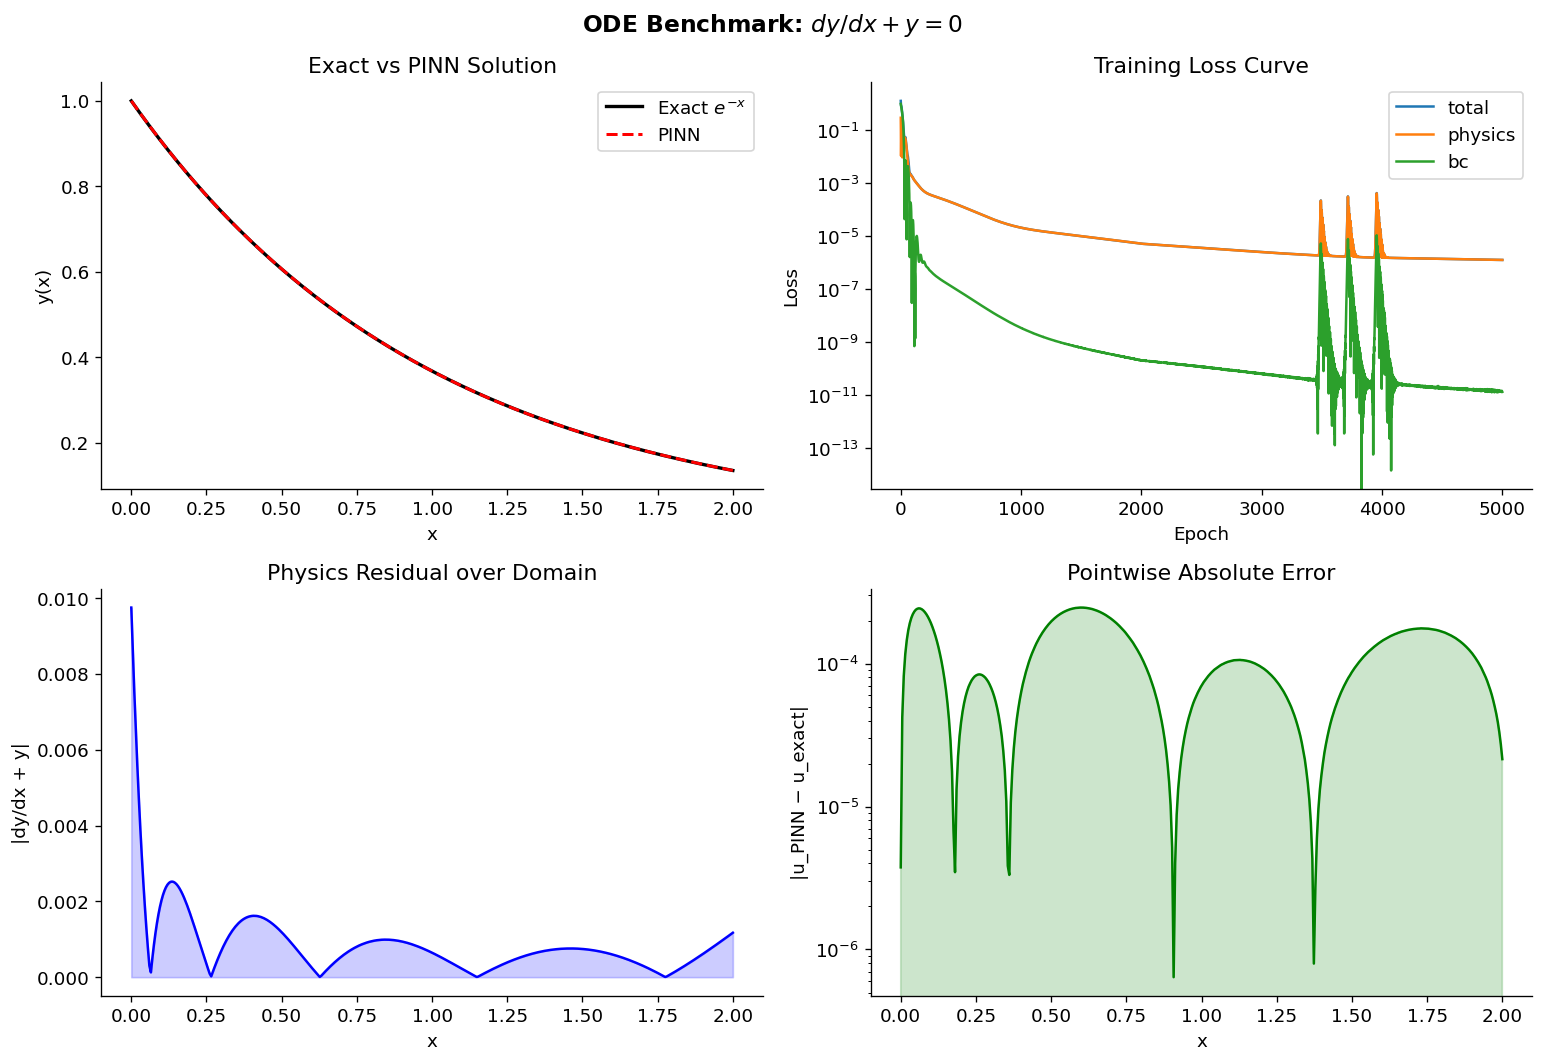


Max absolute error : 2.47e-04
Mean absolute error: 1.12e-04


In [7]:
def evaluate_ode(model):
    """Evaluate PINN vs exact solution on a fine grid."""
    x_np = np.linspace(0, 2, 400).reshape(-1, 1)
    x_t  = to_tensor(x_np)

    model.eval()
    with torch.no_grad():
        u_pred = model(x_t).cpu().numpy()

    u_exact = np.exp(-x_np)          # exact: y = e^{-x}
    return x_np.ravel(), u_pred.ravel(), u_exact.ravel()


def compute_residual_ode(model, x_np):
    """Compute |dy/dx + y| on a numpy grid."""
    x_t = to_tensor(x_np.reshape(-1, 1), requires_grad=True)
    u   = model(x_t)
    du  = torch.autograd.grad(u, x_t,
                              grad_outputs=torch.ones_like(u),
                              create_graph=False)[0]
    res = (du + u).detach().cpu().numpy().ravel()
    return np.abs(res)


x, u_pred, u_exact = evaluate_ode(model_ode)
abs_err  = np.abs(u_pred - u_exact)
residual = compute_residual_ode(model_ode, x)

# ── Four-panel figure ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("ODE Benchmark: $dy/dx + y = 0$", fontsize=14, fontweight="bold")

# Panel 1 — Solution comparison
ax = axes[0, 0]
ax.plot(x, u_exact, "k-",  lw=2,   label="Exact $e^{-x}$")
ax.plot(x, u_pred,  "r--", lw=1.8, label="PINN")
ax.set_xlabel("x"); ax.set_ylabel("y(x)")
ax.set_title("Exact vs PINN Solution")
ax.legend()

# Panel 2 — Training loss
plot_loss(history_ode, title="Training Loss Curve", ax=axes[0, 1])

# Panel 3 — PDE residual over domain
ax = axes[1, 0]
ax.plot(x, residual, "b-", lw=1.5)
ax.set_xlabel("x"); ax.set_ylabel("|dy/dx + y|")
ax.set_title("Physics Residual over Domain")
ax.fill_between(x, residual, alpha=0.2, color="blue")

# Panel 4 — Pointwise absolute error
ax = axes[1, 1]
ax.semilogy(x, abs_err, "g-", lw=1.5)
ax.set_xlabel("x"); ax.set_ylabel("|u_PINN − u_exact|")
ax.set_title("Pointwise Absolute Error")
ax.fill_between(x, abs_err, alpha=0.2, color="green")

plt.tight_layout()
plt.show()

print(f"\nMax absolute error : {abs_err.max():.2e}")
print(f"Mean absolute error: {abs_err.mean():.2e}")

# Example 2

**$$\frac{du}{dt} = u^2(t) + 1,\quad u(0)=0$$**

**LOSS FUNCTION FOR Example II**

$$\mathcal{L}_{total} = \mathcal{L}_{ic} + \mathcal{L}_{res}$$

1. Initial Condition Loss

$$\mathcal{L}_{ic} = \left\|u_\theta(0) - 0\right\|^2$$

2. ODE Residual Loss

$$r(t) = \frac{du_\theta(t)}{dt} - u_\theta^2(t) - 1$$

We sample collocation points uniformly over the domain $t \in [0,1.3]$, the residual loss is the mean squared error of residual values:

$$\mathcal{L}_{res} = \frac{1}{N_r}\sum_{i=1}^{N_r}\left\|r(t_i)\right\|^2$$

Full Combined Loss Function

$$
\mathcal{L}_{total} = \underbrace{\left\|u_\theta(0) - 0\right\|^2}_{\mathcal{L}_{ic}}
+ \lambda \cdot \underbrace{\frac{1}{N_r}\sum_{i=1}^{N_r}\left\|\frac{du_\theta(t_i)}{dt} - u_\theta^2(t_i) - 1\right\|^2}_{\mathcal{L}_{res}}
$$

In [8]:
class PINN_ODE(nn.Module):
    """
    Fully-connected PINN for scalar ODE.
    Input:  x  (scalar, shape [N,1])
    Output: u  (scalar, shape [N,1])
    """
    def __init__(self, hidden_layers=4, hidden_units=32):
        super().__init__()
        layers = [nn.Linear(1, hidden_units), nn.Tanh()]
        for _ in range(hidden_layers - 1):
            layers += [nn.Linear(hidden_units, hidden_units), nn.Tanh()]
        layers += [nn.Linear(hidden_units, 1)]
        self.net = nn.Sequential(*layers)
        self.net.apply(xavier_init)          # Xavier initialisation

    def forward(self, x):
        return self.net(x)
        
#============================================================================================================
def physics_loss_ode(model, x_col):
    """
    Residual 
    Uses autograd to compute dy/dx.
    """
    x_col = x_col.requires_grad_(True)
    u = model(x_col)
    # First derivative via autograd
    du_dx = torch.autograd.grad(
        u, x_col,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]
    residual =du_dx - (u ** 2 + 1)                   # should be ≈ 0
    return torch.mean(residual ** 2)


def bc_loss_ode(model, x_bc, u_bc):
    """Mean-squared error on the initial condition y(0)=1."""
    u_pred = model(x_bc)
    return torch.mean((u_pred - u_bc) ** 2)

#===============================================================================================================
def train_ode(model, n_collocation=500, n_epochs=5000, lr=1e-3, lam=1.0):
    """
    Train the ODE PINN.
    lam : weight on the physics residual loss.
    """
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2000, gamma=0.5)

    # Collocation points uniformly sampled on [0, 1.3]
    x_col = to_tensor(np.random.uniform(0, 1.3, (n_collocation, 1)))

    # Boundary / initial condition  x=0, y=1
    x_bc = to_tensor(np.zeros((1, 1)))
    u_bc = to_tensor(np.zeros((1, 1)))

    history = {"total": [], "physics": [], "bc": []}

    for epoch in range(n_epochs):
        optimizer.zero_grad()

        l_phys = physics_loss_ode(model, x_col)
        l_bc   = bc_loss_ode(model, x_bc, u_bc)
        loss   = l_bc + lam * l_phys

        loss.backward()
        optimizer.step()
        scheduler.step()

        history["total"].append(loss.item())
        history["physics"].append(l_phys.item())
        history["bc"].append(l_bc.item())

        if (epoch + 1) % 1000 == 0:
            print(f"Epoch {epoch+1:5d} | Loss: {loss.item():.2e} "
                  f"| Physics: {l_phys.item():.2e} | BC: {l_bc.item():.2e}")

    return history

In [9]:
seed=1314
torch.manual_seed(seed)
model_ode = PINN_ODE(hidden_layers=4, hidden_units=32).to(device)
print(model_ode)

history_ode = train_ode(model_ode, n_collocation=500, n_epochs=5000, lr=1e-3)

PINN_ODE(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): Tanh()
    (4): Linear(in_features=32, out_features=32, bias=True)
    (5): Tanh()
    (6): Linear(in_features=32, out_features=32, bias=True)
    (7): Tanh()
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)
Epoch  1000 | Loss: 1.57e-02 | Physics: 8.95e-03 | BC: 6.79e-03
Epoch  2000 | Loss: 1.09e-02 | Physics: 6.66e-03 | BC: 4.28e-03
Epoch  3000 | Loss: 7.40e-03 | Physics: 5.03e-03 | BC: 2.38e-03
Epoch  4000 | Loss: 6.33e-03 | Physics: 4.62e-03 | BC: 1.71e-03
Epoch  5000 | Loss: 5.32e-03 | Physics: 3.72e-03 | BC: 1.61e-03


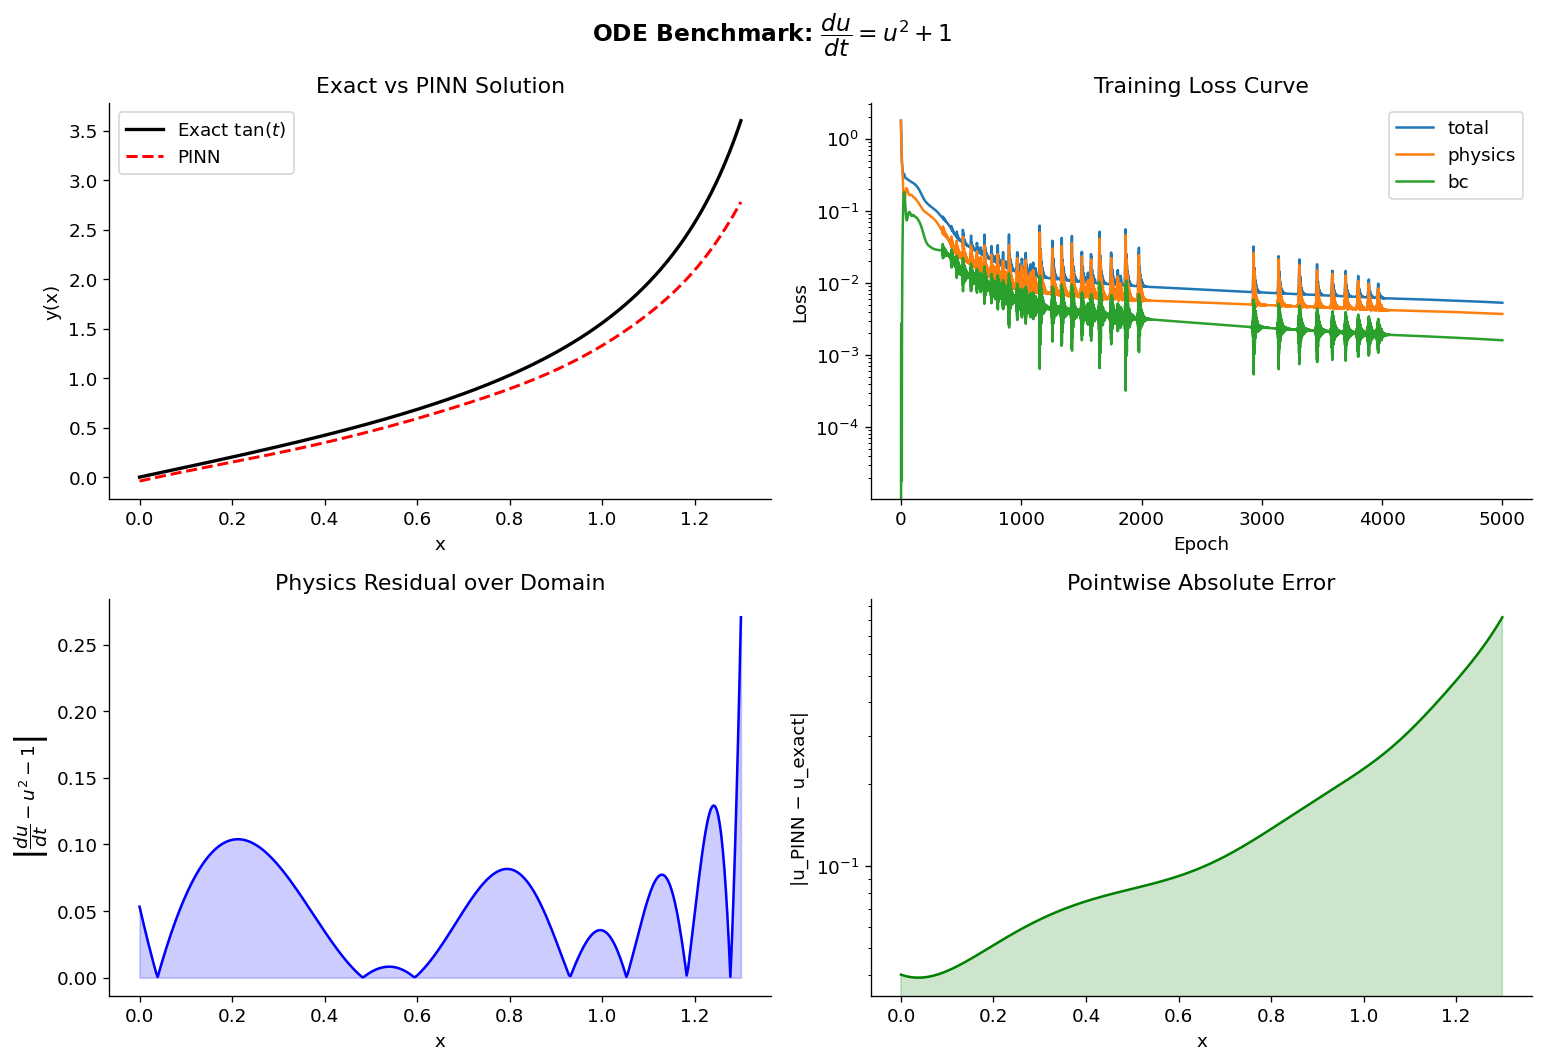


Max absolute error : 8.21e-01
Mean absolute error: 1.73e-01


In [10]:
def evaluate_ode(model):
    x_np = np.linspace(0, 1.3, 400).reshape(-1, 1)
    x_t  = to_tensor(x_np)

    model.eval()
    with torch.no_grad():
        u_pred = model(x_t).cpu().numpy()

    u_exact = np.tan(x_np)          # exact: new
    return x_np.ravel(), u_pred.ravel(), u_exact.ravel()


def compute_residual_ode(model, x_np):
    x_t = to_tensor(x_np.reshape(-1, 1), requires_grad=True)
    u   = model(x_t)
    du  = torch.autograd.grad(u, x_t,
                              grad_outputs=torch.ones_like(u),
                              create_graph=False)[0]
    res = (du - (u ** 2 + 1)).detach().cpu().numpy().ravel()
    return np.abs(res)

#===================================================================================================================
x, u_pred, u_exact = evaluate_ode(model_ode)
abs_err  = np.abs(u_pred - u_exact)
residual = compute_residual_ode(model_ode, x)

# ── Four-panel figure ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle(r"ODE Benchmark: $\dfrac{du}{dt} = u^2 + 1$", fontsize=14, fontweight="bold")

# Panel 1 — Solution comparison
ax = axes[0, 0]
ax.plot(x, u_exact, "k-",  lw=2,   label=r"Exact $\tan(t)$")
ax.plot(x, u_pred,  "r--", lw=1.8, label="PINN")
ax.set_xlabel("x"); ax.set_ylabel("y(x)")
ax.set_title("Exact vs PINN Solution")
ax.legend()

# Panel 2 — Training loss
plot_loss(history_ode, title="Training Loss Curve", ax=axes[0, 1])

# Panel 3 — PDE residual over domain
ax = axes[1, 0]
ax.plot(x, residual, "b-", lw=1.5)
ax.set_xlabel("x"); ax.set_ylabel(r"$\left|\dfrac{du}{dt} - u^2 - 1\right|$")
ax.set_title("Physics Residual over Domain")
ax.fill_between(x, residual, alpha=0.2, color="blue")

# Panel 4 — Pointwise absolute error
ax = axes[1, 1]
ax.semilogy(x, abs_err, "g-", lw=1.5)
ax.set_xlabel("x"); ax.set_ylabel("|u_PINN − u_exact|")
ax.set_title("Pointwise Absolute Error")
ax.fill_between(x, abs_err, alpha=0.2, color="green")

plt.tight_layout()
plt.show()

print(f"\nMax absolute error : {abs_err.max():.2e}")
print(f"Mean absolute error: {abs_err.mean():.2e}")

# Overall Conclusion Summary

**This set of visualization results fully validates the effectiveness of PINN on this simple ODE benchmark. The model successfully balances two core objectives: fitting the initial value constraint and obeying the differential equation rule. Both the visual curve overlap and numerical error metrics confirm that Physics-Informed Neural Networks can act as a reliable mesh-free numerical solver for ordinary differential equations, even without massive labeled training data.**